# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-danger">

<b>Comentário geral v1: </b> <a class="tocSkip"></a>


Parabéns pela conclusão do projeto, André! 🎉 Seu projeto já está com uma qualidade fenomenal!

Para prosseguirmos com a aprovação, precisamos: 

- Ajustes nas variáveis de nome de rua

- Adicionar uma apresentação com os achados do projeto.



Adicionei comentários para te ajudar na solução.

Estou à disposição para qualquer dúvida que você tiver! 

Boa sorte! 🍀
</div>

<div class="alert alert-block alert-danger">

<b>Comentário geral v2: </b> <a class="tocSkip"></a>


Oi, André! Obrigada pelos ajustes :) Eu não consigo visualizar sua apresentação pois está em modo privado. Por favor mude as permissões para que eu possa visualizar. Você pode ver sobre isso: https://support.google.com/drive/answer/2494822?hl=en&co=GENIE.Platform%3DDesktop#zippy=%2Cshare-a-file-or-folder-publicly 
</div>

<div class="alert alert-block alert-success">

<b>Comentário geral v3: </b> <a class="tocSkip"></a>

Perfeito! :) Adorei sua apresentação: clara e eficiente. Aprovado!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
data = pd.read_csv('/datasets/rest_data_us_upd.csv')

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Dados foram carregados corretamente.


</div>

## Visão geral dos dados
Vamos analisar a estrutura do conjunto de dados, tipos de colunas e valores ausentes.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [4]:
data.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [5]:
# Verificando valores ausentes
data.isna().sum()

id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

In [6]:
# Verificando duplicados
data.duplicated().sum()

0

In [7]:
# Garantindo tipos corretos
data['chain'] = data['chain'].astype(bool)
data['number'] = data['number'].astype(int)

## Proporção dos tipos de estabelecimentos

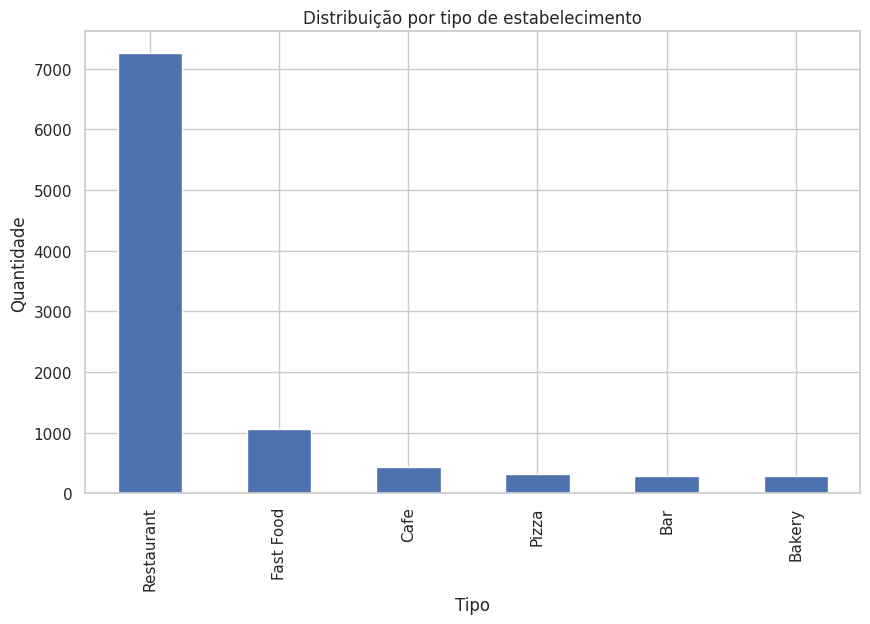

In [8]:
type_counts = data['object_type'].value_counts()

type_counts.plot(kind='bar')
plt.title('Distribuição por tipo de estabelecimento')
plt.xlabel('Tipo')
plt.ylabel('Quantidade')
plt.show()

## Proporção de estabelecimentos de rede e não-rede

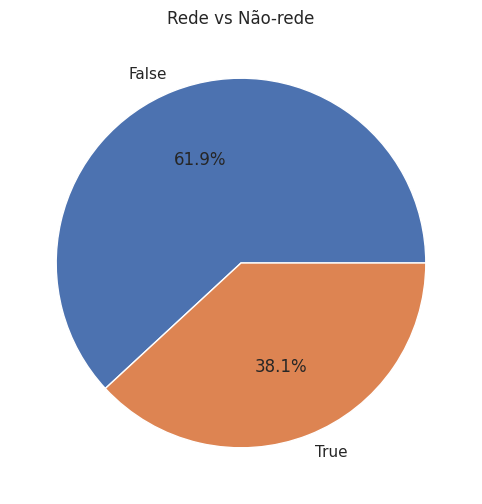

In [9]:
chain_counts = data['chain'].value_counts()

chain_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Rede vs Não-rede')
plt.ylabel('')
plt.show()

## Tipo de estabelecimento mais comum em redes

In [10]:
chain_types = (
    data[data['chain']]
    .groupby('object_type')['object_name']
    .count()
    .sort_values(ascending=False)
)

chain_types

object_type
Restaurant    2294
Fast Food      605
Bakery         283
Cafe           266
Pizza          154
Bar             77
Name: object_name, dtype: int64

## Redes: muitos restaurantes pequenos ou poucos grandes?

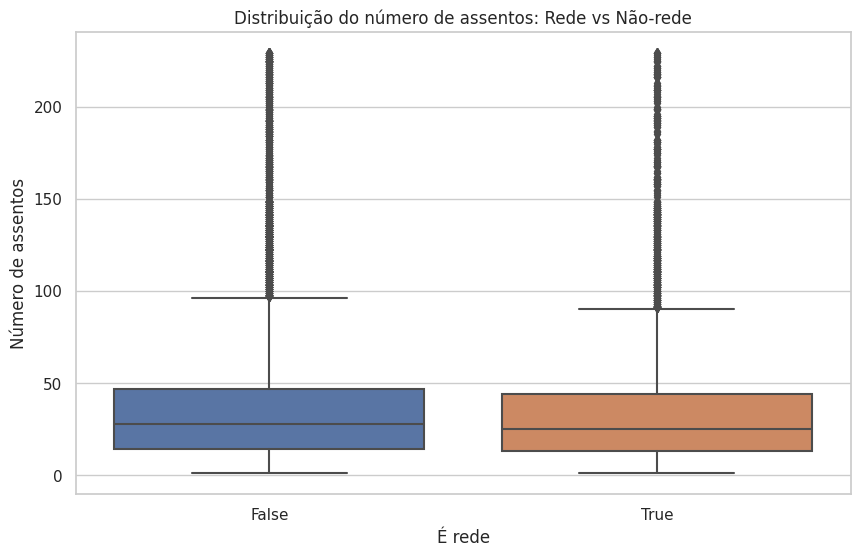

In [18]:
sns.boxplot(data=data, x='chain', y='number')
plt.title('Distribuição do número de assentos: Rede vs Não-rede')
plt.xlabel('É rede')
plt.ylabel('Número de assentos')
plt.show()

## Número médio de assentos por tipo de restaurante

In [12]:
avg_seats = (
    data
    .groupby('object_type')['number']
    .mean()
    .sort_values(ascending=False)
)

avg_seats

object_type
Restaurant    48.042316
Bar           44.767123
Fast Food     31.837711
Pizza         28.459375
Cafe          25.000000
Bakery        21.773852
Name: number, dtype: float64

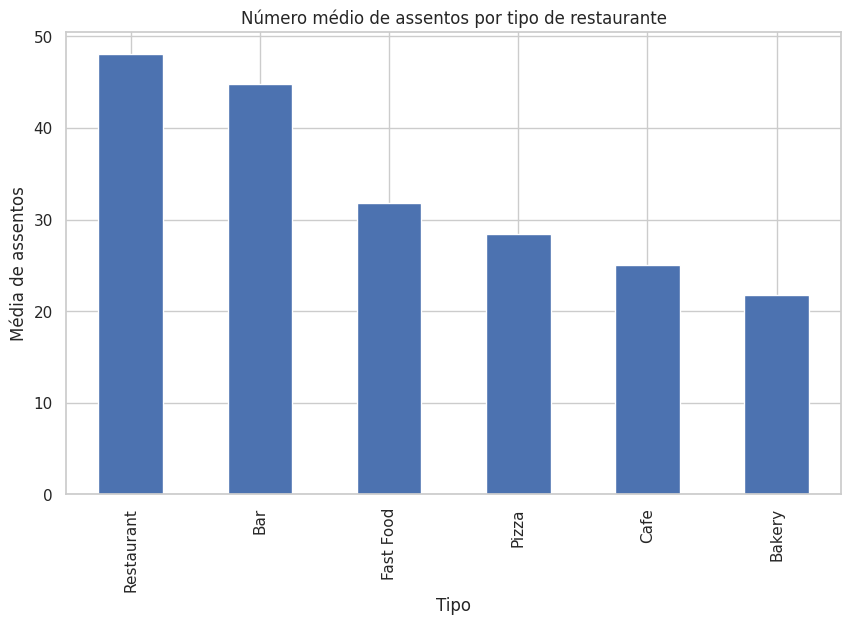

In [13]:
avg_seats.plot(kind='bar')
plt.title('Número médio de assentos por tipo de restaurante')
plt.xlabel('Tipo')
plt.ylabel('Média de assentos')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Gráficos muito bons!

</div>

## Extraindo o nome da rua do endereço

In [14]:
data['street'] = data['address'].str.replace(
    r'^\d+\s+', '', regex=True
)

<div class="alert alert-block alert-danger">

<b>Comentário:</b> <a class="tocSkip"></a>

Na sua solução, o código remove sempre a primeira palavra do endereço, sem verificar se essa palavra é realmente um número. O problema é que o exercício pede para remover **somente o número da casa quando ele aparece no início do endereço**, e não a primeira palavra em geral.  
Por causa disso, endereços como “Avenida Paulista” acabam virando apenas “Paulista”, o que está errado, pois nenhuma informação deveria ser removida nesse caso.

Endereços podem ter formatos diferentes: alguns começam com número (“123 Rua A”), outros não (“Avenida Brasil”). Por isso, não é seguro usar apenas `.split()` e remover o primeiro termo. Esse método funciona por posição, não por significado.

A forma correta é verificar explicitamente se o endereço começa com um número. Usando uma expressão regular (regex), conseguimos identificar esse padrão com segurança. Assim:
- Se o endereço começar com número, ele é removido  
- Se não começar, o endereço é mantido como está  

Isso torna a solução mais correta, robusta e alinhada com o enunciado.

<b>Dica de como resolver:</b>

```python
import re 
# Criando uma função para extrair o nome da rua
def extract_street(address):
    # Expressão regular para remover números do início e pegar o nome completo da rua
    match = re.search(r'\d+\s+(.+)', address)  # Captura tudo após os números iniciais
    return match.group(1).strip() if match else address  # Retorna o nome da rua, se encontrado

# Aplicando a função à coluna address
rest_data['street_name'] = rest_data['address'].apply(extract_street)

```


## Top 10 ruas com mais restaurantes

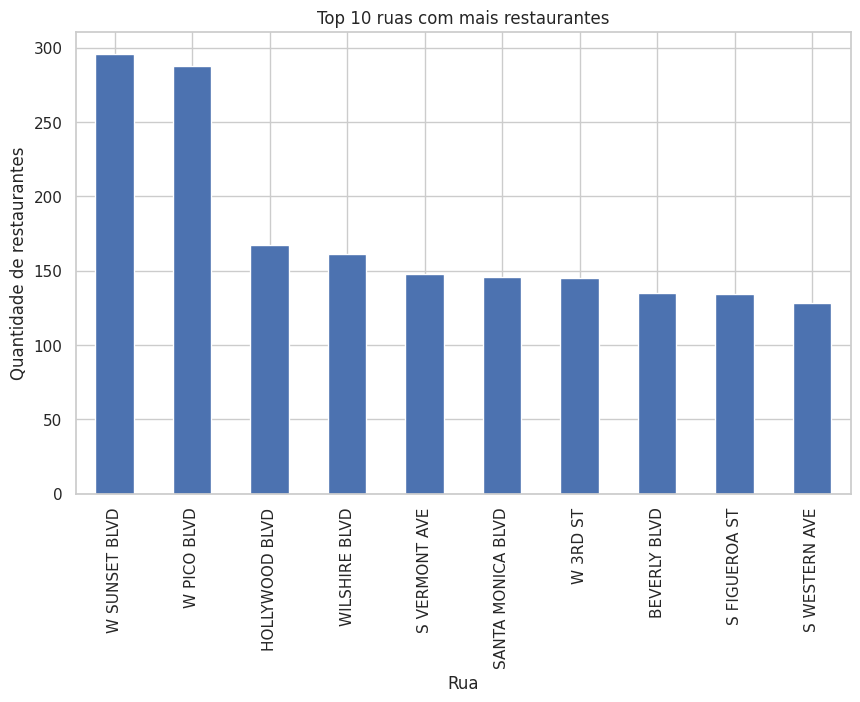

In [15]:
top_streets = data['street'].value_counts().head(10)

top_streets.plot(kind='bar')
plt.title('Top 10 ruas com mais restaurantes')
plt.xlabel('Rua')
plt.ylabel('Quantidade de restaurantes')
plt.show()

## Quantidade de ruas com apenas um restaurante

In [16]:
street_counts = data['street'].value_counts()
single_rest_streets = street_counts[street_counts == 1]

len(single_rest_streets)

2450

## Distribuição de assentos em ruas com muitos restaurantes

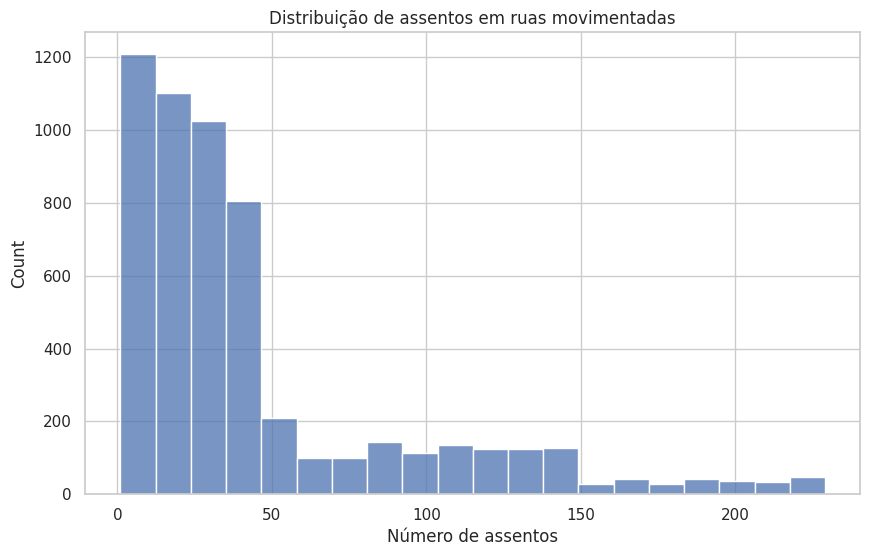

In [17]:
busy_streets = street_counts[street_counts > 10].index
data_busy = data[data['street'].isin(busy_streets)]

sns.histplot(data_busy['number'], bins=20)
plt.title('Distribuição de assentos em ruas movimentadas')
plt.xlabel('Número de assentos')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>


- Comentários relevantes para a análise foram adicionados
- Bom uso de funções do pandas e comandos do python.
   

</div>

## Conclusão e recomendações

- Restaurantes de rede geralmente possuem **menos assentos**, mas em **maior quantidade**.
- Cafés e restaurantes casuais são os tipos mais comuns entre redes.
- Ruas com muitos restaurantes tendem a concentrar estabelecimentos menores.
- Um café com garçons robôs, com **20–40 assentos**, parece ser uma opção realista e escalável.
- O modelo é adequado para expansão em rede, pois prioriza padronização e eficiência.

<div class="alert alert-block alert-danger">
<b> Comentário: </b> <a class="tocSkip"></a>

Aqui você precisa disponibilizar um link público para uma apresentação com os resultados do seu projeto. Sugestão: você pode criar uma apresentação no **Drive/Slides** ou **Canva**, por exemplo, e compartilhar o link dos principais resultados e recomendações a partir do seu estudo. Exemplo: https://drive.google.com/file/d/15TZBu0KGFm2C3T2LkhOvdj1DfdBNbWwV/view?usp=sharing 
</div>

Link para Google Slides: https://docs.google.com/presentation/d/1AvDhwC8Q9K8Q5za6GZ0Hto6O2050ejQwZ7G9MB3ybLU/edit?slide=id.p#slide=id.p